<a href="https://colab.research.google.com/github/comparativechrono/bioinformatics_reddit_study/blob/main/bioinformatics_reddit_study_with_BERTopics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Did LLMs Reshape Bioinformatics Q&A on Reddit?
## Full Analysis Pipeline — Google Colab Notebook

This notebook runs the complete study: data acquisition → classification → topic modeling → ITS → DiD → 7 hypothesis tests → 7 figures.

> **Data sources:** Arctic Shift API (primary, full history) → PullPush (fallback, mostly 2023+) → bulk dumps (manual, most reliable).
> **Runtime:** Download takes 1–4 hours. Analysis + figures take ~5 minutes.

In [ ]:
!unzip bioinformatics_reddit_study_2.zip -d /content/

Archive:  bioinformatics_reddit_study_2.zip
  inflating: /content/bioinformatics_reddit_study.ipynb  
 extracting: /content/pipeline/__init__.py  
  inflating: /content/pipeline/config.py  
  inflating: /content/pipeline/data_acquisition.py  
  inflating: /content/pipeline/classifier.py  
  inflating: /content/pipeline/analysis.py  
  inflating: /content/pipeline/visualize.py  


## 0. Setup

In [ ]:
# Install dependencies (BERTopic requires GPU runtime for speed)
# Runtime → Change runtime type → T4 GPU (recommended)
!pip install -q requests pandas numpy scipy scikit-learn matplotlib seaborn
!pip install -q bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 6.2 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive for persistent checkpoints
from google.colab import drive
drive.mount("/content/drive")

import os
WORK_DIR = "/content/drive/MyDrive/bioinfo_reddit_study"
for d in ["checkpoints", "output", "figures", "tables"]:
    os.makedirs(f"{WORK_DIR}/{d}", exist_ok=True)
print(f"Working directory: {WORK_DIR}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/bioinfo_reddit_study


In [ ]:
import sys
sys.path.insert(0, "/content/pipeline")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import config
from data_acquisition import (
    download_all_subreddits, load_from_checkpoints, load_from_jsonl,
    print_bulk_dump_instructions, test_arctic_shift_availability,
    test_pullpush_availability
)
from classifier import classify_dataframe, add_feature_columns
from analysis import (
    preprocess, run_topic_modeling, run_its_analysis,
    run_placebo_tests, run_did_analysis, test_all_hypotheses,
    analyze_deletion_rates, cross_subreddit_analysis
)
from visualize import generate_all_figures

config.CHECKPOINT_DIR = f"{WORK_DIR}/checkpoints"
print("All modules loaded.")

All modules loaded.


## 1. Data Acquisition

The notebook first tests Arctic Shift (which has complete historical data back to 2014). If Arctic Shift is down, it falls back to PullPush (which mostly only has 2023+ data). If both fail, it prints instructions for the bulk dump approach.

**Choose ONE of the three cells below based on your situation.**

### Option C: Load from .jsonl file (Arctic Shift download tool or bulk dumps)
If you downloaded .jsonl files manually (from the Arctic Shift download tool at arctic-shift.photon-reddit.com/download-tool, or from bulk .zst dumps), upload them to Google Drive and load here.

In [ ]:
# Load from .jsonl file(s) — uncomment and edit paths
# df_raw = load_from_jsonl("/content/drive/MyDrive/bioinformatics_submissions.jsonl")
#
# Or load multiple files and combine:
dfs = []
for f in ["r_bioinformatics", "r_learnbioinformatics", "r_genomics", "r_CompBio", "r_NGS", "r_labrats"]:
    path = f"/content/{f}_posts.jsonl"
    if os.path.exists(path):
        dfs.append(load_from_jsonl(path))
df_raw = pd.concat(dfs, ignore_index=True)

# Show bulk dump instructions if needed:
# print_bulk_dump_instructions()

Loaded 36,151 posts from /content/r_bioinformatics_posts.jsonl
  Subreddits: 1
  Date range: 2014-01-02 19:05:25 to 2026-05-12 19:43:08
  2014: 606
  2015: 925
  2016: 1,164
  2017: 1,511
  2018: 1,628
  2019: 2,353
  2020: 3,999
  2021: 3,884
  2022: 3,625
  2023: 4,240
  2024: 5,725
  2025: 5,145
  2026: 1,346
Loaded 522 posts from /content/r_learnbioinformatics_posts.jsonl
  Subreddits: 1
  Date range: 2015-07-23 22:35:20 to 2026-05-11 18:44:30
  2015: 39
  2016: 116
  2017: 3
  2018: 13
  2019: 50
  2020: 56
  2021: 49
  2022: 16
  2023: 42
  2024: 57
  2025: 46
  2026: 35
Loaded 1,413 posts from /content/r_genomics_posts.jsonl
  Subreddits: 1
  Date range: 2014-01-12 20:09:35 to 2026-05-12 15:26:07
  2014: 39
  2015: 25
  2016: 67
  2017: 39
  2018: 64
  2019: 120
  2020: 134
  2021: 165
  2022: 98
  2023: 142
  2024: 197
  2025: 233
  2026: 90
Loaded 25 posts from /content/r_CompBio_posts.jsonl
  Subreddits: 1
  Date range: 2016-02-16 22:18:02 to 2026-04-20 00:44:17
  2016: 1
  2

In [ ]:
# Data overview
print(f"Total posts: {len(df_raw):,}")
print(f"Date range: {df_raw['created_utc'].min()} to {df_raw['created_utc'].max()}")
print(f"Posts per subreddit:")
print(df_raw["subreddit"].value_counts().to_string())
print(f"Posts per year:")
print(df_raw.groupby(df_raw["created_utc"].dt.year).size().to_string())

# Coverage check
pre_2020 = df_raw[df_raw["created_utc"].dt.year < 2020]
post_2022 = df_raw[df_raw["created_utc"].dt.year >= 2023]
print(f"Pre-2020 posts: {len(pre_2020):,}")
print(f"Post-2022 posts: {len(post_2022):,}")
if len(pre_2020) < 500:
    print("⚠ INSUFFICIENT HISTORICAL DATA for pre-LLM comparison.")
    print("Use Option C with Arctic Shift download tool or bulk dumps.")
    print_bulk_dump_instructions()

Total posts: 122,544
Date range: 2014-01-02 01:13:47 to 2026-05-12 19:43:08
Posts per subreddit:
subreddit
r/labrats                84320
r/bioinformatics         36151
r/genomics                1413
r/learnbioinformatics      522
r/ngs                      113
r/compbio                   25
Posts per year:
created_utc
2014     1773
2015     3049
2016     3996
2017     4923
2018     6163
2019     7978
2020     9984
2021    10220
2022    12321
2023    15385
2024    20724
2025    19863
2026     6165
Pre-2020 posts: 27,882
Post-2022 posts: 62,137


## 2. Classification
Classifies each post into 8 categories (adapted Beyer et al. 2020 taxonomy) using regex patterns and keyword scoring. For the paper, validate with a manually-labeled sample of ~1,200 posts.

In [ ]:
df = classify_dataframe(df_raw)
df = add_feature_columns(df)
print(f"Classified {len(df):,} posts")

  Classifying posts...

  Classification distribution:
    Tool selection / Comparison        :  43.6%
    Career / Meta                      :  16.2%
    Errors / Debugging                 :  11.7%
    other                              :   8.0%
    Learning / Getting started         :   7.9%
    Tool usage / How-to                :   5.5%
    Conceptual / Theory                :   4.4%
    Experimental design                :   1.7%
    Result interpretation              :   1.1%

  Mean confidence: 0.684
  Unclassified ('other'): 9,788 (8.0%)
Classified 122,544 posts


## 3. Preprocessing & Descriptive Statistics

In [ ]:
df = preprocess(df)
df.to_csv(f"{WORK_DIR}/output/processed_posts.csv", index=False)


═══ PREPROCESSING ═══
  Total posts: 122,544
    pre_llm: 27,873 (22.7%)
    pandemic: 9,963 (8.1%)
    transition: 22,528 (18.4%)
    post_llm: 62,137 (50.7%)


In [ ]:
# Table 1: Dataset overview
overview = df.groupby(["subreddit","era"]).agg(
    n_posts=("post_id","count"), mean_score=("score","mean"),
    mean_comments=("num_comments","mean"), pct_llm=("has_llm_mention","mean")
).round(3)
overview.to_csv(f"{WORK_DIR}/tables/table1_overview.csv")
display(overview)

n_posts  mean_score  mean_comments  pct_llm
subreddit             era                                                    
r/bioinformatics      other            19       8.737          7.895    0.000
                      pandemic       3989       6.639          6.381    0.000
                      post_llm      16456       5.860          5.724    0.016
                      pre_llm        8183       6.045          7.863    0.000
                      transition     7504       8.143          6.856    0.001
r/compbio             pandemic          3       1.333          0.333    0.000
                      post_llm         16       0.938          0.062    0.000
                      pre_llm           3       1.667          0.667    0.000
                      transition        3       1.000          0.000    0.000
r/genomics            pandemic        134       4.313          3.104    0.000
                      post_llm        662       2.588          2.814    0.020
                      pre_llm         354       3.121          2.955    0.003
                      transition      263       8.616          4.403    0.000
r/labrats             other            24      11.958         13.917    0.000
                      pandemic       5771      12.471          5.789    0.000
                      post_llm      44761      37.280         12.958    0.005
                      pre_llm       19088       7.105          8.617    0.000
                      transition    14676      19.042          9.524    0.000
r/learnbioinformatics pandemic         56       3.429          1.518    0.000
                      post_llm        180       2.878          1.256    0.006
                      pre_llm         221       2.855          1.208    0.000
                      transition       65       3.554          1.877    0.000
r/ngs                 pandemic         10       1.400          0.400    0.000
                      post_llm         62       1.887          2.339    0.000
                      pre_llm          24       1.542          1.542    0.000
                      transition       17       2.118          0.882    0.000

In [ ]:
# Table 2: Category distribution by era (r/bioinformatics)
bio = df[df["subreddit"]=="r/bioinformatics"]
cat_dist = pd.crosstab(bio["era"], bio["category_label"], normalize="index").round(4)*100
cat_dist.to_csv(f"{WORK_DIR}/tables/table2_categories.csv")
display(cat_dist.style.format("{:.1f}%").background_gradient(cmap="RdYlGn_r",axis=1))

category_label,Career / Meta,Conceptual / Theory,Errors / Debugging,Experimental design,Learning / Getting started,Other / Unclassified,Result interpretation,Tool selection / Comparison,Tool usage / How-to
era,,,,,,,,,
other,21.1%,5.3%,0.0%,0.0%,10.5%,26.3%,5.3%,26.3%,5.3%
pandemic,15.1%,4.3%,8.0%,1.9%,15.4%,8.0%,1.5%,38.5%,7.4%
post_llm,18.6%,4.6%,10.7%,2.8%,14.0%,2.1%,1.9%,37.4%,8.0%
pre_llm,17.1%,4.6%,8.3%,2.0%,14.3%,4.7%,1.2%,40.4%,7.4%
transition,16.0%,4.7%,8.3%,2.0%,14.9%,5.9%,1.4%,38.8%,8.2%


## 4. Topic Modeling (BERTopic)

Uses BERTopic with a biomedical sentence-transformer () for domain-appropriate embeddings. Falls back to NMF if BERTopic is not installed.

BERTopic uses UMAP → HDBSCAN → c-TF-IDF to discover topics automatically (no need to specify n_topics). Outlier posts are assigned topic -1 and excluded from diversity calculations.

> **GPU recommended.** BERTopic embedding is ~10x faster on T4 GPU. Set runtime via Runtime → Change runtime type → T4 GPU.

In [ ]:
# BERTopic with biomedical SBERT (primary), NMF fallback if not installed
# Set use_bertopic=False to force NMF, or adjust min_topic_size
text_df, topic_labels, topic_prevalence, topic_diversity = run_topic_modeling(
    df, n_topics=15, use_bertopic=True, min_topic_size=None
)

# Save topic labels
topic_df = pd.DataFrame([{"topic": k, "terms": v} for k, v in topic_labels.items()])
topic_df.to_csv(f"{WORK_DIR}/tables/table3_topics.csv", index=False)
display(topic_df)


═══ TOPIC MODELING (BERTopic + biomedical SBERT) ═══
  Loading biomedical embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  Fitting BERTopic (min_topic_size=15)...


Batches:   0%|          | 0/3455 [00:00<?, ?it/s]

2026-05-13 10:34:12,536 - BERTopic - Embedding - Completed ✓
2026-05-13 10:34:12,537 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-13 10:34:52,712 - BERTopic - Dimensionality - Completed ✓
2026-05-13 10:34:52,713 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 10:34:57,876 - BERTopic - Cluster - Completed ✓
2026-05-13 10:34:57,877 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-13 10:35:03,245 - BERTopic - Representation - Completed ✓
2026-05-13 10:35:03,252 - BERTopic - Topic reduction - Reducing number of topics
2026-05-13 10:35:03,634 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 10:35:08,851 - BERTopic - Representation - Completed ✓
2026-05-13 10:35:08,863 - BERTopic - Topic reduction - Reduced number of topics from 423 to 14



  BERTopic found 13 topics
  Outlier posts (topic -1): 64,274 (58.1%)
  Topic   0 (45,327 posts): the, to, and, of, in
  Topic   1 (  337 posts): your, friday, failure, thread, success
  Topic   2 (  157 posts): discord, week, us, glory, risen
  Topic   3 (  131 posts): vent, thread, discord, rant, 385mcqr
  Topic   4 (  110 posts): will, be, given, point, posts
  Topic   5 (   77 posts): week, risen, glory, kidding, sun
  Topic   6 (   27 posts): skin, spilled, blue, scar, buffer
  Topic   7 (   25 posts): discord, thread, humpday, fliers, greener
  Topic   8 (   23 posts): poll, com, imgur, https, child
  Topic   9 (   18 posts): lego, ideas, 46ec, 49e7, b844
  Topic  10 (   17 posts): cjc, ipamorelin, 1295, dac, vial
  Topic  11 (   16 posts): poll, removed, view, virginity, reddit
  Topic  12 (   16 posts): jove, video, access, videos, https
  Mean quarterly topic diversity (Shannon H): 0.242


,topic,terms
0,-1,Outlier / Unassigned
1,0,"the, to, and, of, in"
2,1,"your, friday, failure, thread, success"
3,2,"discord, week, us, glory, risen"
4,3,"vent, thread, discord, rant, 385mcqr"
5,4,"will, be, given, point, posts"
6,5,"week, risen, glory, kidding, sun"
7,6,"skin, spilled, blue, scar, buffer"
8,7,"discord, thread, humpday, fliers, greener"
9,8,"poll, com, imgur, https, child"


## 5. Interrupted Time Series

In [ ]:
its_full, its_key, weekly_share = run_its_analysis(df, subreddit="r/bioinformatics")
its_full.to_csv(f"{WORK_DIR}/tables/table4_its.csv", index=False)
if len(its_key)>0:
    display(its_key[["category_label","displacement","parameter","coefficient","p_value","significant_fdr"]])


═══ ITS ANALYSIS (r/bioinformatics) ═══

  Key ITS results:
  *** Career / Meta                  | adoption_curve   | β=+0.14399 | p=0.0000
  *** Career / Meta                  | slope_change     | β=-0.00048 | p=0.0003
  *** Result interpretation          | slope_change     | β=+0.00011 | p=0.0032
      Career / Meta                  | level_shift      | β=-0.07044 | p=0.0096
      Tool selection / Comparison    | slope_change     | β=+0.00030 | p=0.0573
      Experimental design            | slope_change     | β=+0.00009 | p=0.0760
      Errors / Debugging             | slope_change     | β=+0.00015 | p=0.0938
      Errors / Debugging             | level_shift      | β=+0.02594 | p=0.1663
      Tool usage / How-to            | level_shift      | β=+0.02178 | p=0.2159
      Result interpretation          | adoption_curve   | β=-0.01045 | p=0.2689
      Learning / Getting started     | level_shift      | β=-0.02642 | p=0.2998
      Tool usage / How-to            | adoption_curve   | β

,category_label,displacement,parameter,coefficient,p_value,significant_fdr
39,Career / Meta,none,adoption_curve,0.143987,0.000019,True
38,Career / Meta,none,slope_change,-0.000481,0.000291,True
33,Result interpretation,low,slope_change,0.000110,0.003189,True
37,Career / Meta,none,level_shift,-0.070437,0.009585,False
28,Tool selection / Comparison,medium,slope_change,0.000303,0.057304,False
23,Experimental design,low,slope_change,0.000086,0.075966,False
8,Errors / Debugging,high,slope_change,0.000153,0.093755,False
7,Errors / Debugging,high,level_shift,0.025938,0.166326,False
2,Tool usage / How-to,high,level_shift,0.021781,0.215925,False
34,Result interpretation,low,adoption_curve,-0.010451,0.268859,False


## 6. Placebo Checks

In [ ]:
placebo = run_placebo_tests(df, subreddit="r/bioinformatics")
placebo.to_csv(f"{WORK_DIR}/tables/table5_placebo.csv", index=False)


═══ PLACEBO CHECKS ═══
    alphafold2                | tool_usage           | β=-0.00973 | p=0.6244
    alphafold2                | errors               | β=+0.00294 | p=0.8895
    alphafold2                | experimental_design  | β=-0.00684 | p=0.5409
    reddit_api_changes        | tool_usage           | β=+0.01453 | p=0.5310
    reddit_api_changes        | errors               | β=+0.00101 | p=0.9674
    reddit_api_changes        | experimental_design  | β=-0.00734 | p=0.5749
    gpt4_release              | tool_usage           | β=+0.00914 | p=0.6828
    gpt4_release              | errors               | β=-0.02475 | p=0.2988
    gpt4_release              | experimental_design  | β=-0.01019 | p=0.4191


## 7. Difference-in-Differences

In [ ]:
did_results = run_did_analysis(df)
pd.DataFrame([{"spec":k,**v} for k,v in did_results.items()]).to_csv(
    f"{WORK_DIR}/tables/table6_did.csv", index=False)


═══ DIFFERENCE-IN-DIFFERENCES ═══

  A) Between-subreddit (bioinformatics subs vs labrats)
        high_share          : DiD = +0.1286 (p=0.1392)
        cx                  : DiD = +0.1175 (p=0.2706)
    *** comments            : DiD = -5.2724 (p=0.0000)

  B) Within-subreddit (high vs low displacement, r/bioinformatics)
    DiD: +0.0318 (p=0.3454)


## 8. Hypothesis Tests

In [ ]:
hyp = test_all_hypotheses(df)
hyp.to_csv(f"{WORK_DIR}/tables/table7_hypotheses.csv", index=False)
display(hyp[["hypothesis","description","pre_value","post_value","effect_size","p_value","significant_fdr"]])


═══ HYPOTHESIS TESTS ═══

  Results:
  ✓ H2    | Question complexity increases            |        1.789 →        1.953 | p=0.0000
  ✓ H6    | Beginner share declines                  |        0.085 →        0.075 | p=0.0000
  ✓ H3a   | Total volume does NOT decline            |      341/qtr →     1175/qtr | p=0.0000
  ✓ H1    | High-displacement shares decline         |        0.300 →        0.326 | p=0.0000
  ✓ H4    | Topic diversity increases                |      H=2.499 →      H=2.574 | p=0.0017
  ✗ H3b   | Displaceable volume declines             |      102/qtr →      384/qtr | p=1.0000
  ✗ H5    | Engagement improves                      |         7.86 →         5.72 | p=1.0000
  ✗ H7    | Career/meta NO break (control)           |        0.170 →        0.186 | p=0.0032


,hypothesis,description,pre_value,post_value,effect_size,p_value,significant_fdr
0,H2,Question complexity increases,1.789,1.953,d=0.204,1.523878e-34,True
1,H6,Beginner share declines,0.085,0.075,-0.010 pp,1.669824e-07,True
2,H3a,Total volume does NOT decline,341/qtr,1175/qtr,ratio=3.45,1.190473e-06,True
3,H1,High-displacement shares decline,0.300,0.326,+0.026 pp,3.638482e-05,True
4,H4,Topic diversity increases,H=2.499,H=2.574,ΔH=+0.076,1.748906e-03,True
5,H3b,Displaceable volume declines,102/qtr,384/qtr,ratio=3.75,9.999994e-01,False
6,H5,Engagement improves,7.86,5.72,Δ=-2.14,1.000000e+00,False
7,H7,Career/meta NO break (control),0.170,0.186,+0.015 pp,3.180263e-03,False


## 9. Supplementary Analyses

In [ ]:
deletion = analyze_deletion_rates(df)
deletion.to_csv(f"{WORK_DIR}/tables/table8_deletion.csv", index=False)
cross_sub = cross_subreddit_analysis(df)
cross_sub.to_csv(f"{WORK_DIR}/tables/table9_cross_sub.csv", index=False)


═══ DELETION RATES ═══
  post_llm   | control_category       | 0.012 (135/11014)
  post_llm   | high_displacement      | 0.011 (168/15844)
  post_llm   | low_displacement       | 0.008 (16/1952)
  post_llm   | medium_displacement    | 0.016 (474/30044)
  post_llm   | unclassified           | 0.217 (714/3283)
  pre_llm    | control_category       | 0.065 (253/3890)
  pre_llm    | high_displacement      | 0.059 (418/7131)
  pre_llm    | low_displacement       | 0.039 (27/695)
  pre_llm    | medium_displacement    | 0.090 (1229/13694)
  pre_llm    | unclassified           | 0.691 (1702/2463)

═══ CROSS-SUBREDDIT ═══
  r/learnbioinformatics     | Δ high-disp=-0.294 | Δ complexity=+0.159
  r/labrats                 | Δ high-disp=-0.004 | Δ complexity=+0.167
  r/bioinformatics          | Δ high-disp=+0.026 | Δ complexity=+0.164
  r/genomics                | Δ high-disp=+0.034 | Δ complexity=+0.322


## 10. Publication Figures

In [ ]:
FIG_DIR = f"{WORK_DIR}/figures"
generate_all_figures(df, topic_diversity, cross_sub, FIG_DIR)
print("All figures saved.")


═══ GENERATING FIGURES ═══
  Saved: /content/drive/MyDrive/bioinfo_reddit_study/figures/fig1_volume_category_trends.png
  Saved: /content/drive/MyDrive/bioinfo_reddit_study/figures/fig2_displacement_shift.png
  Saved: /content/drive/MyDrive/bioinfo_reddit_study/figures/fig3_its_timeseries.png
  Saved: /content/drive/MyDrive/bioinfo_reddit_study/figures/fig4_did_parallel_trends.png
  Saved: /content/drive/MyDrive/bioinfo_reddit_study/figures/fig5_complexity_engagement.png
  Saved: /content/drive/MyDrive/bioinfo_reddit_study/figures/fig6_cross_subreddit.png
  Saved: /content/drive/MyDrive/bioinfo_reddit_study/figures/fig7_topic_diversity.png
  All 7 figures saved to /content/drive/MyDrive/bioinfo_reddit_study/figures/
All figures saved.


fig1_volume_category_trends.png


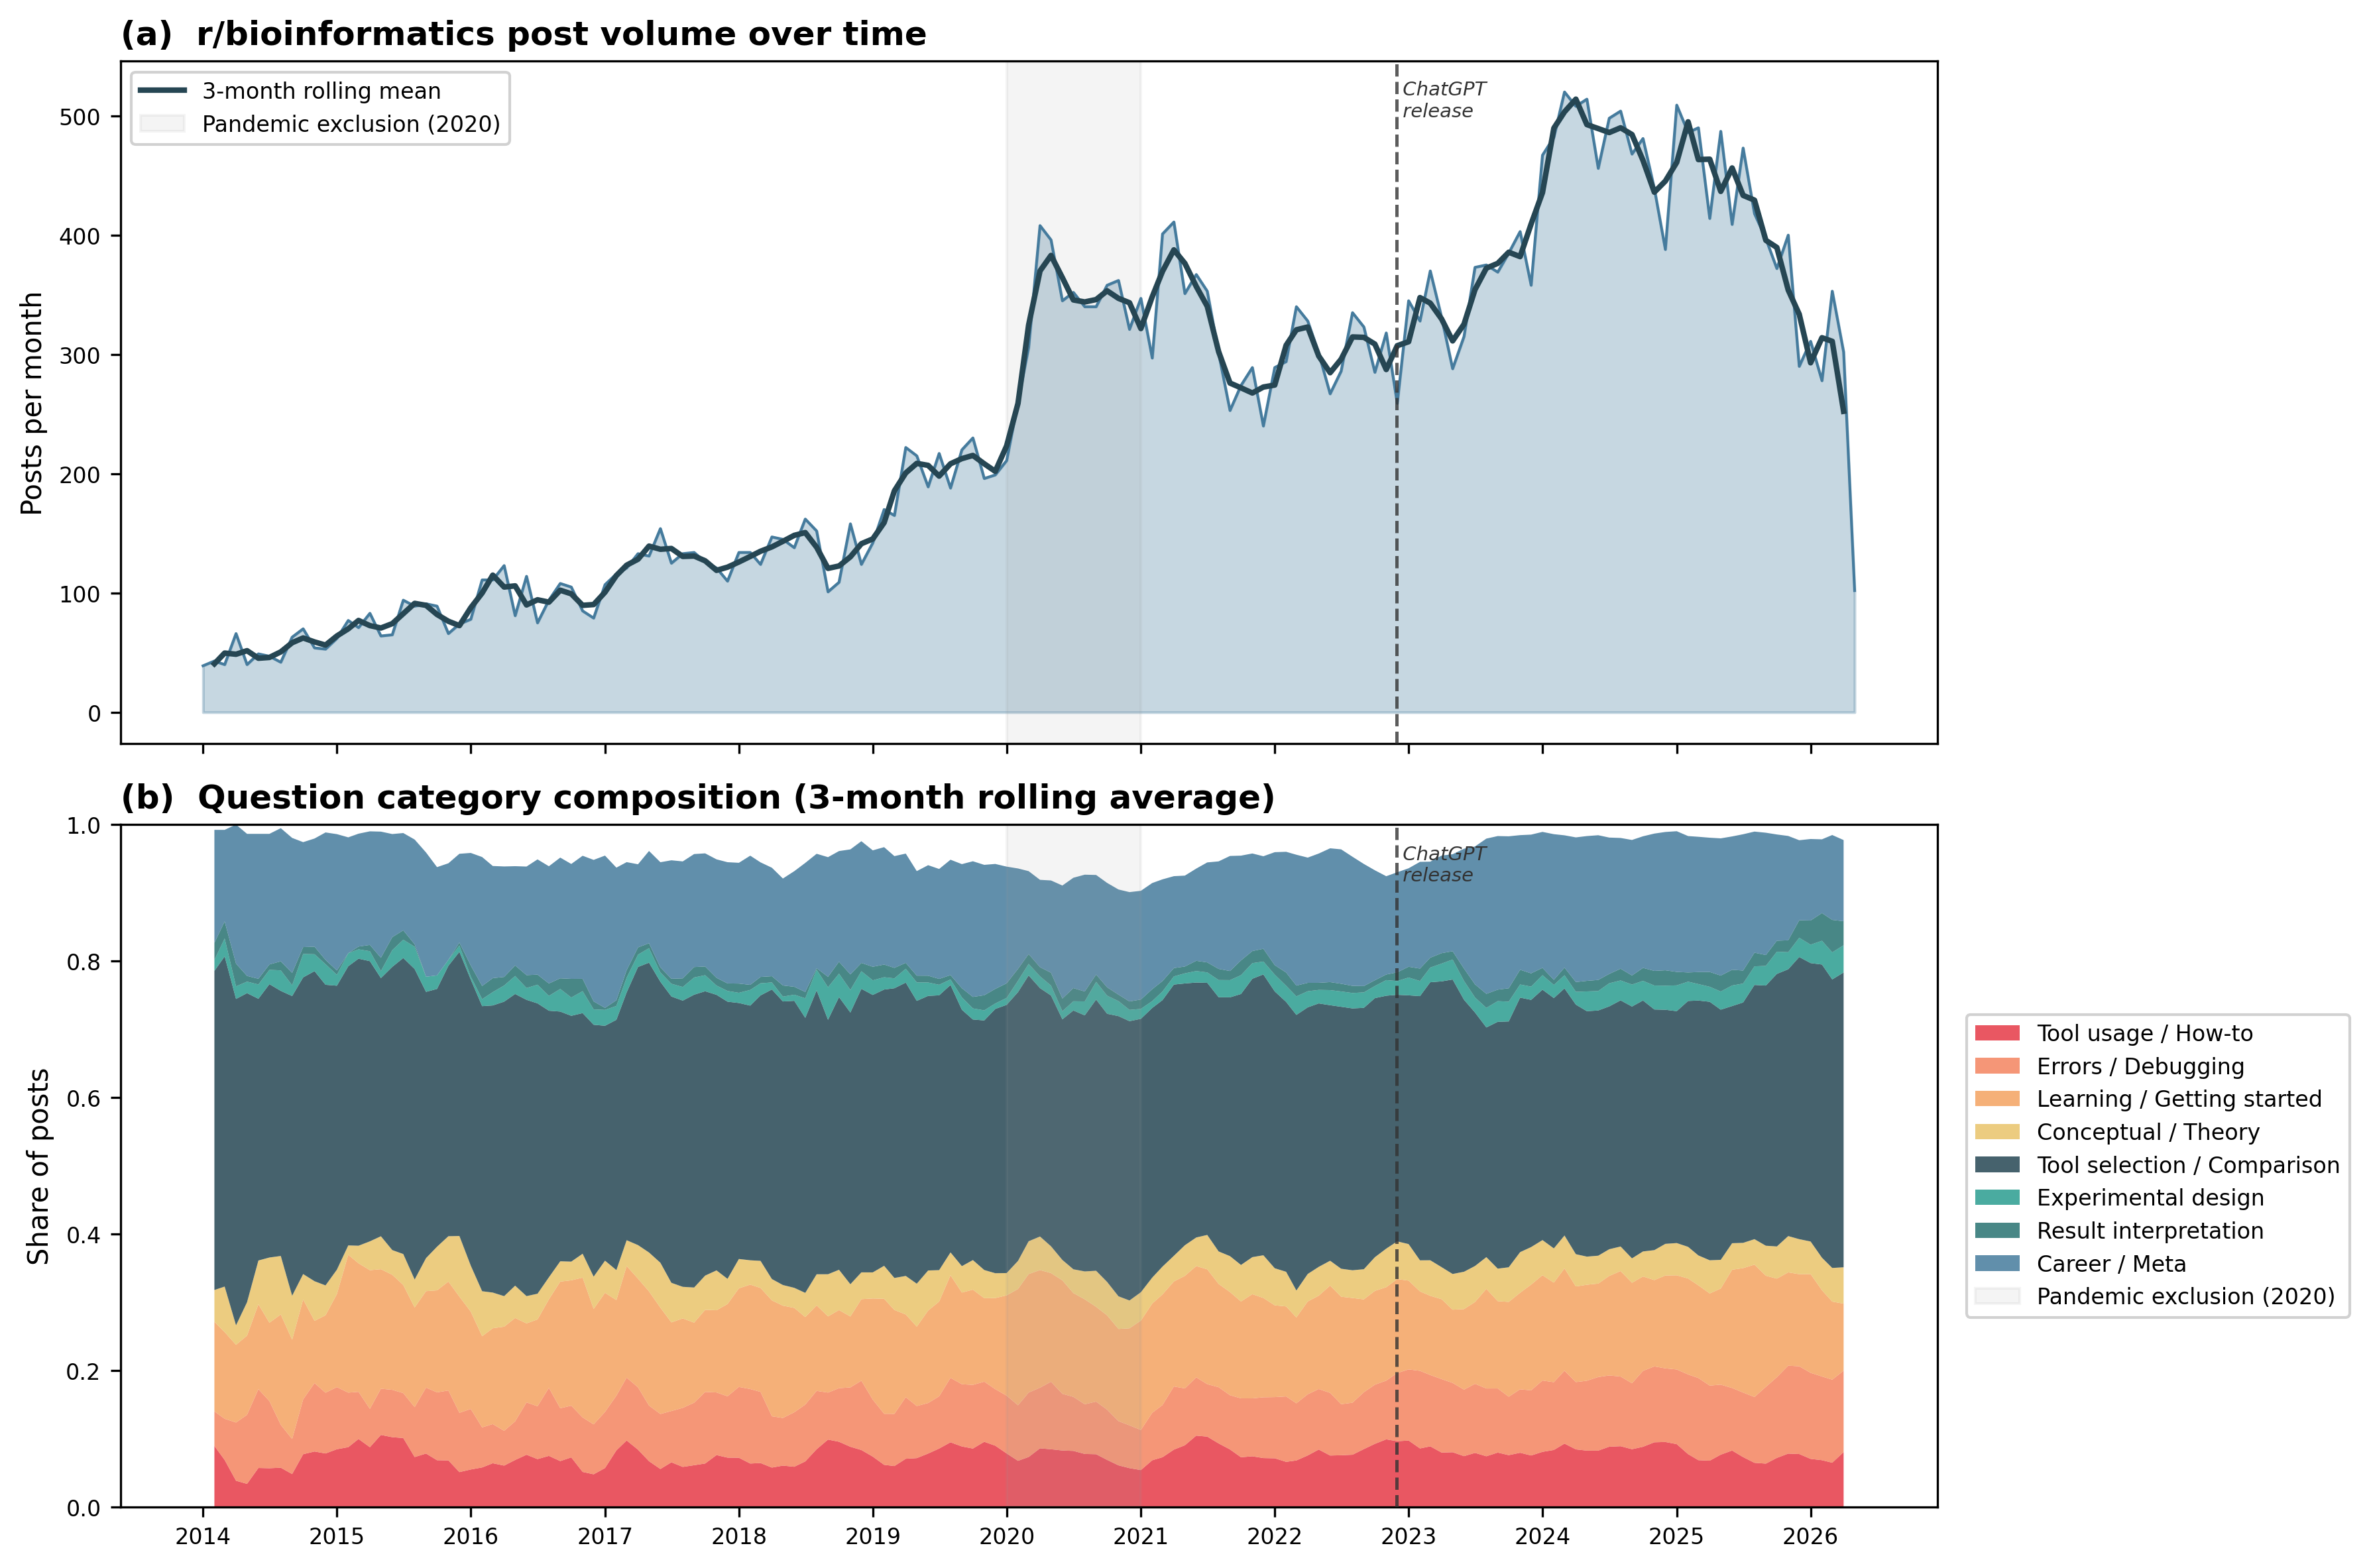

fig2_displacement_shift.png


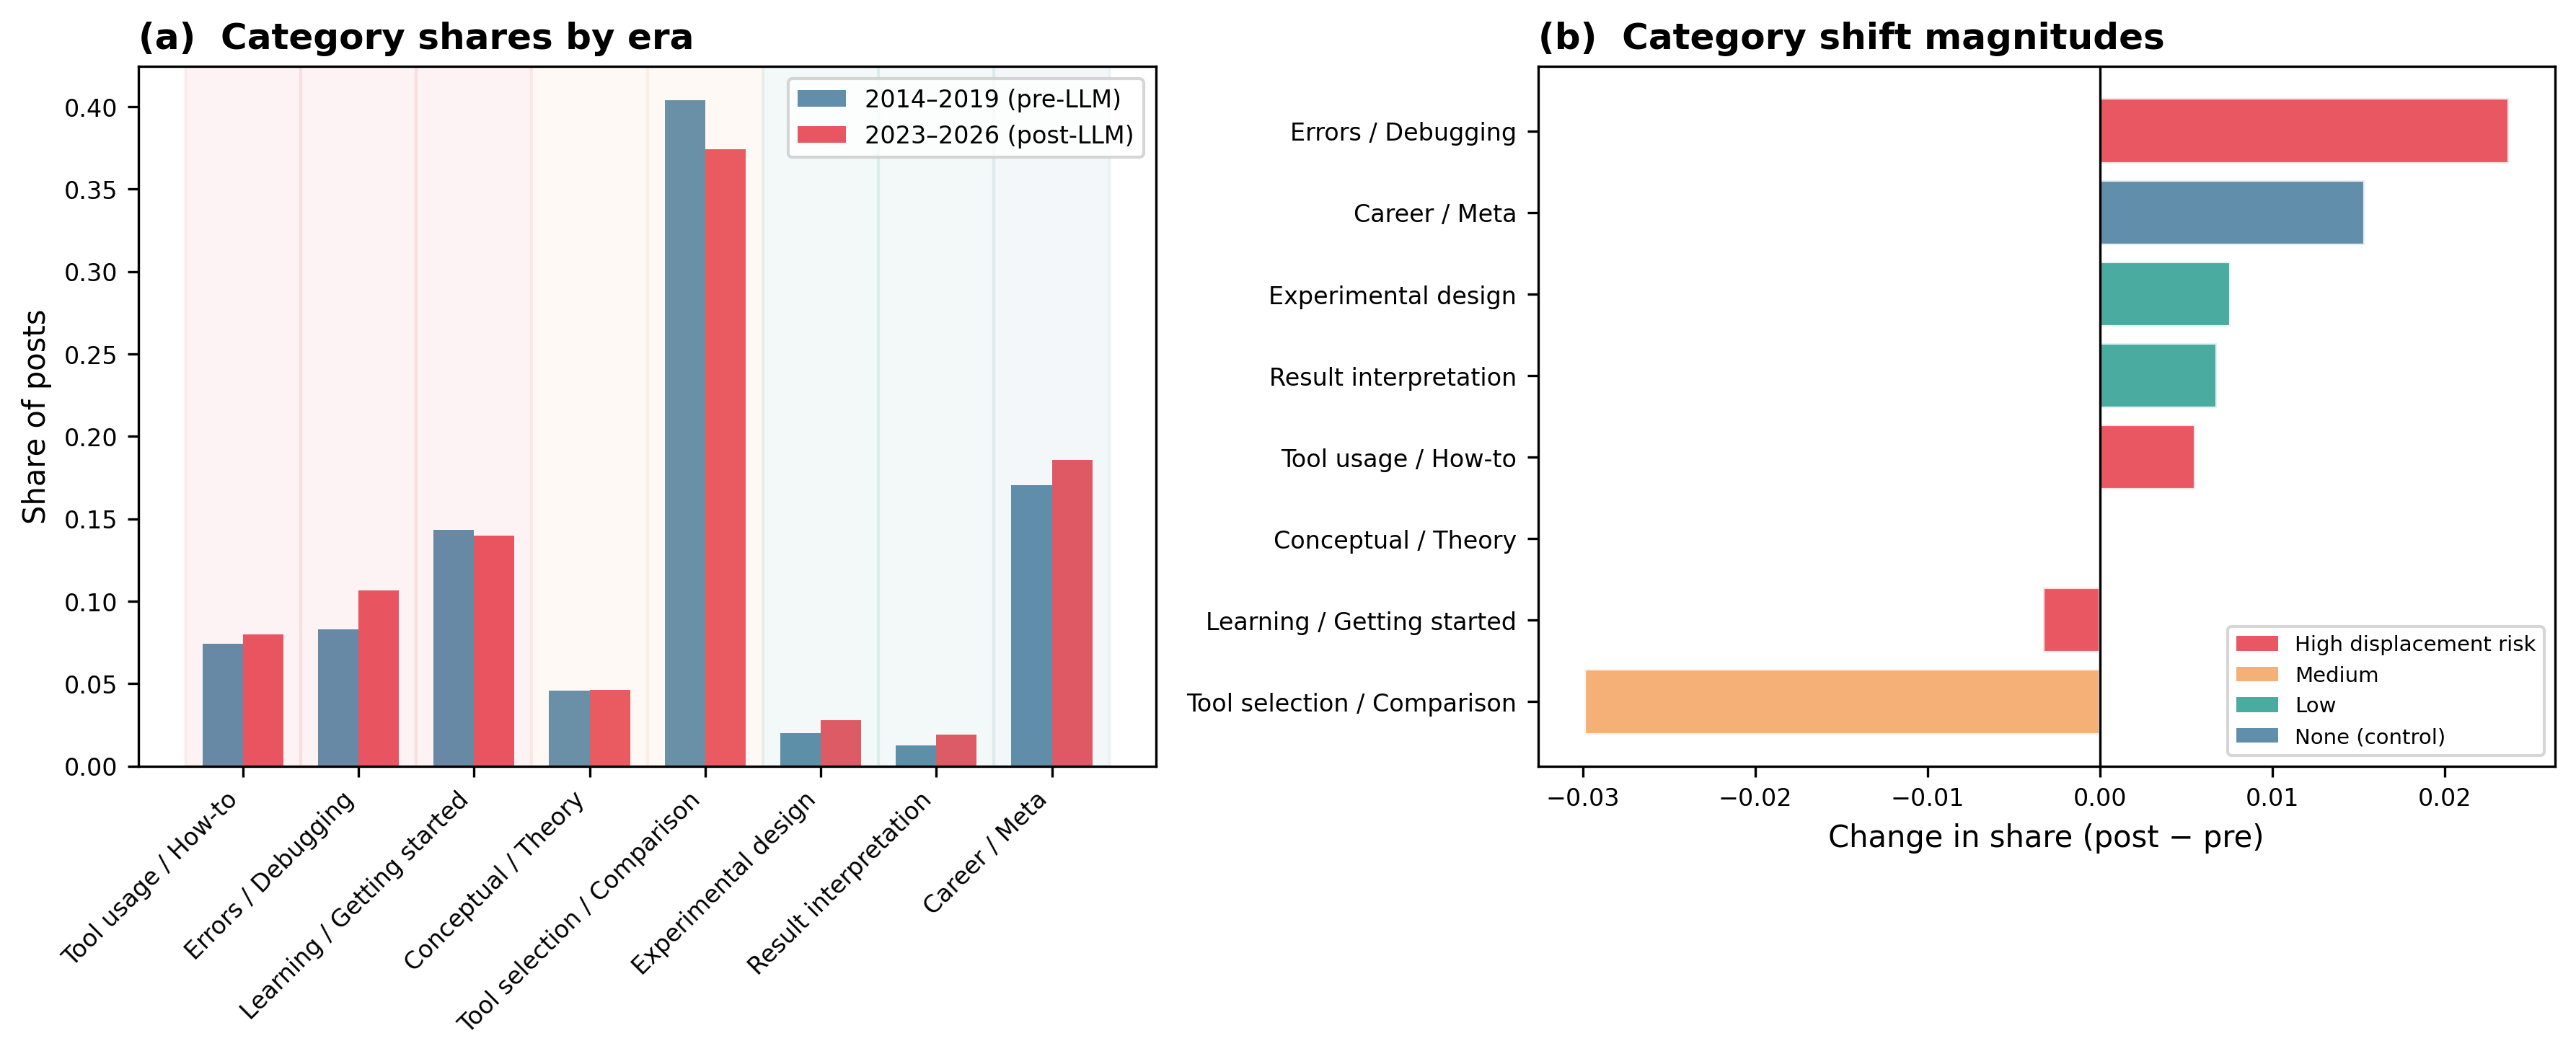

fig3_its_timeseries.png


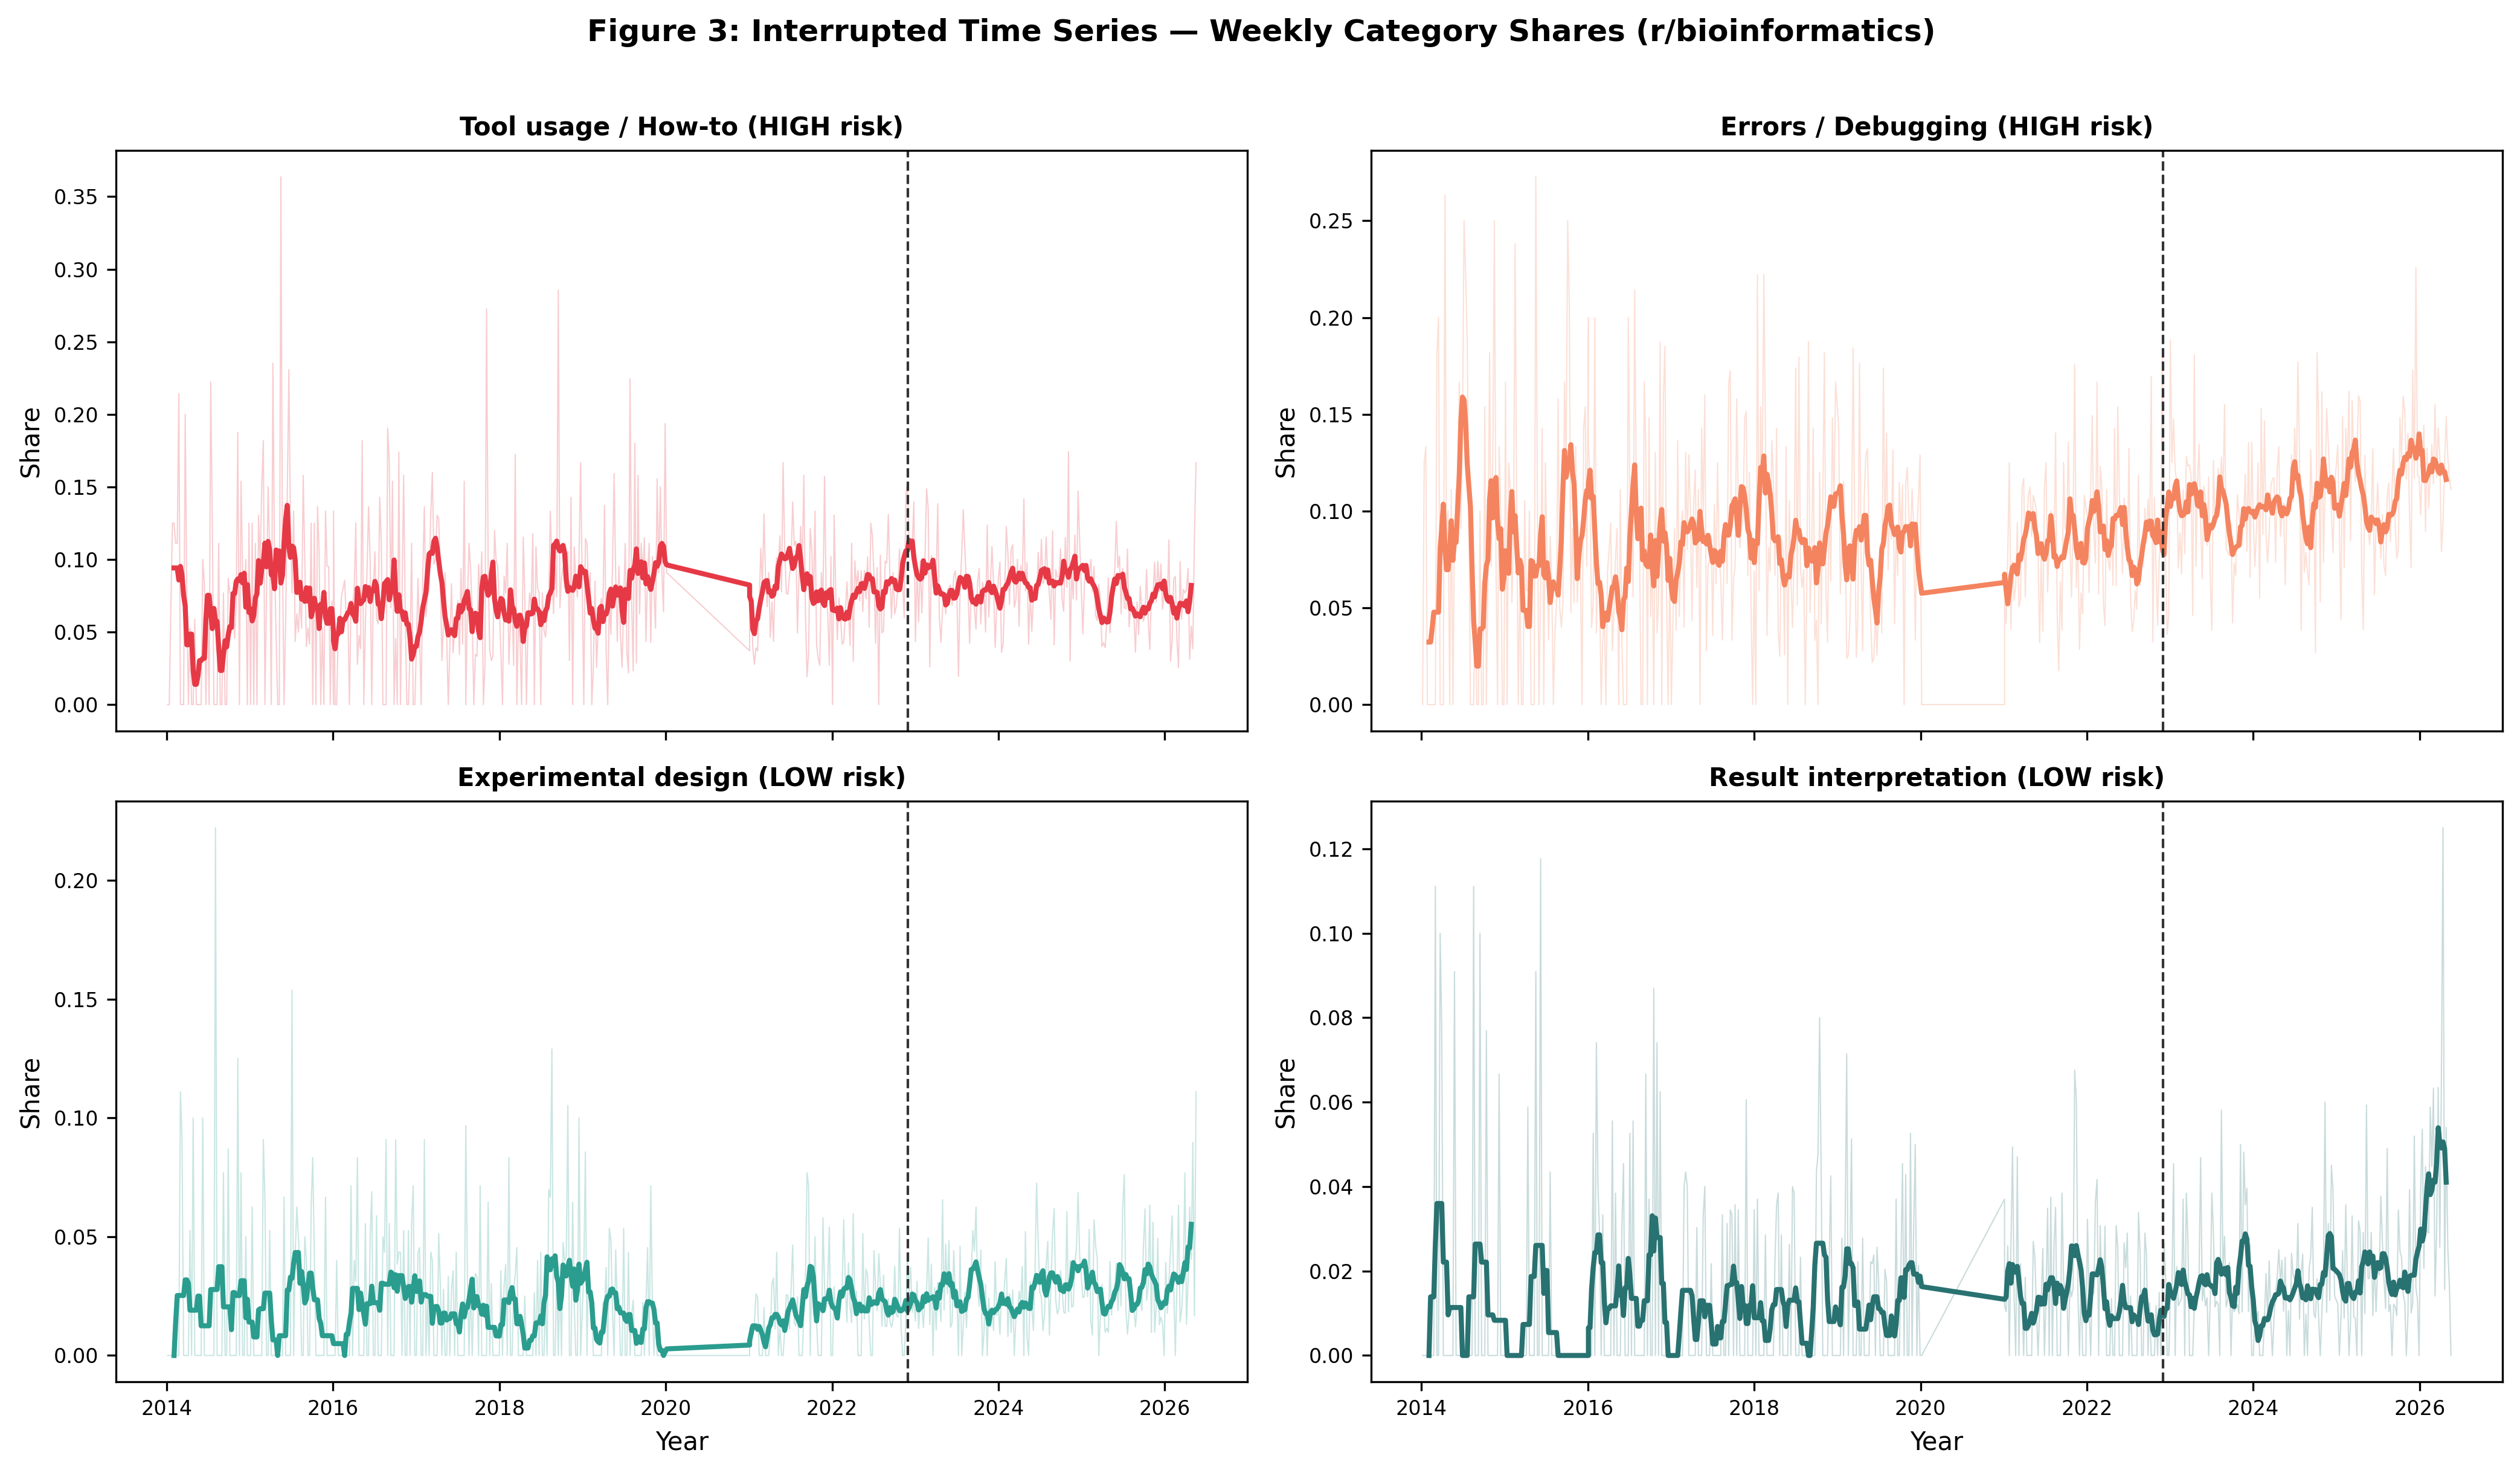

fig4_did_parallel_trends.png


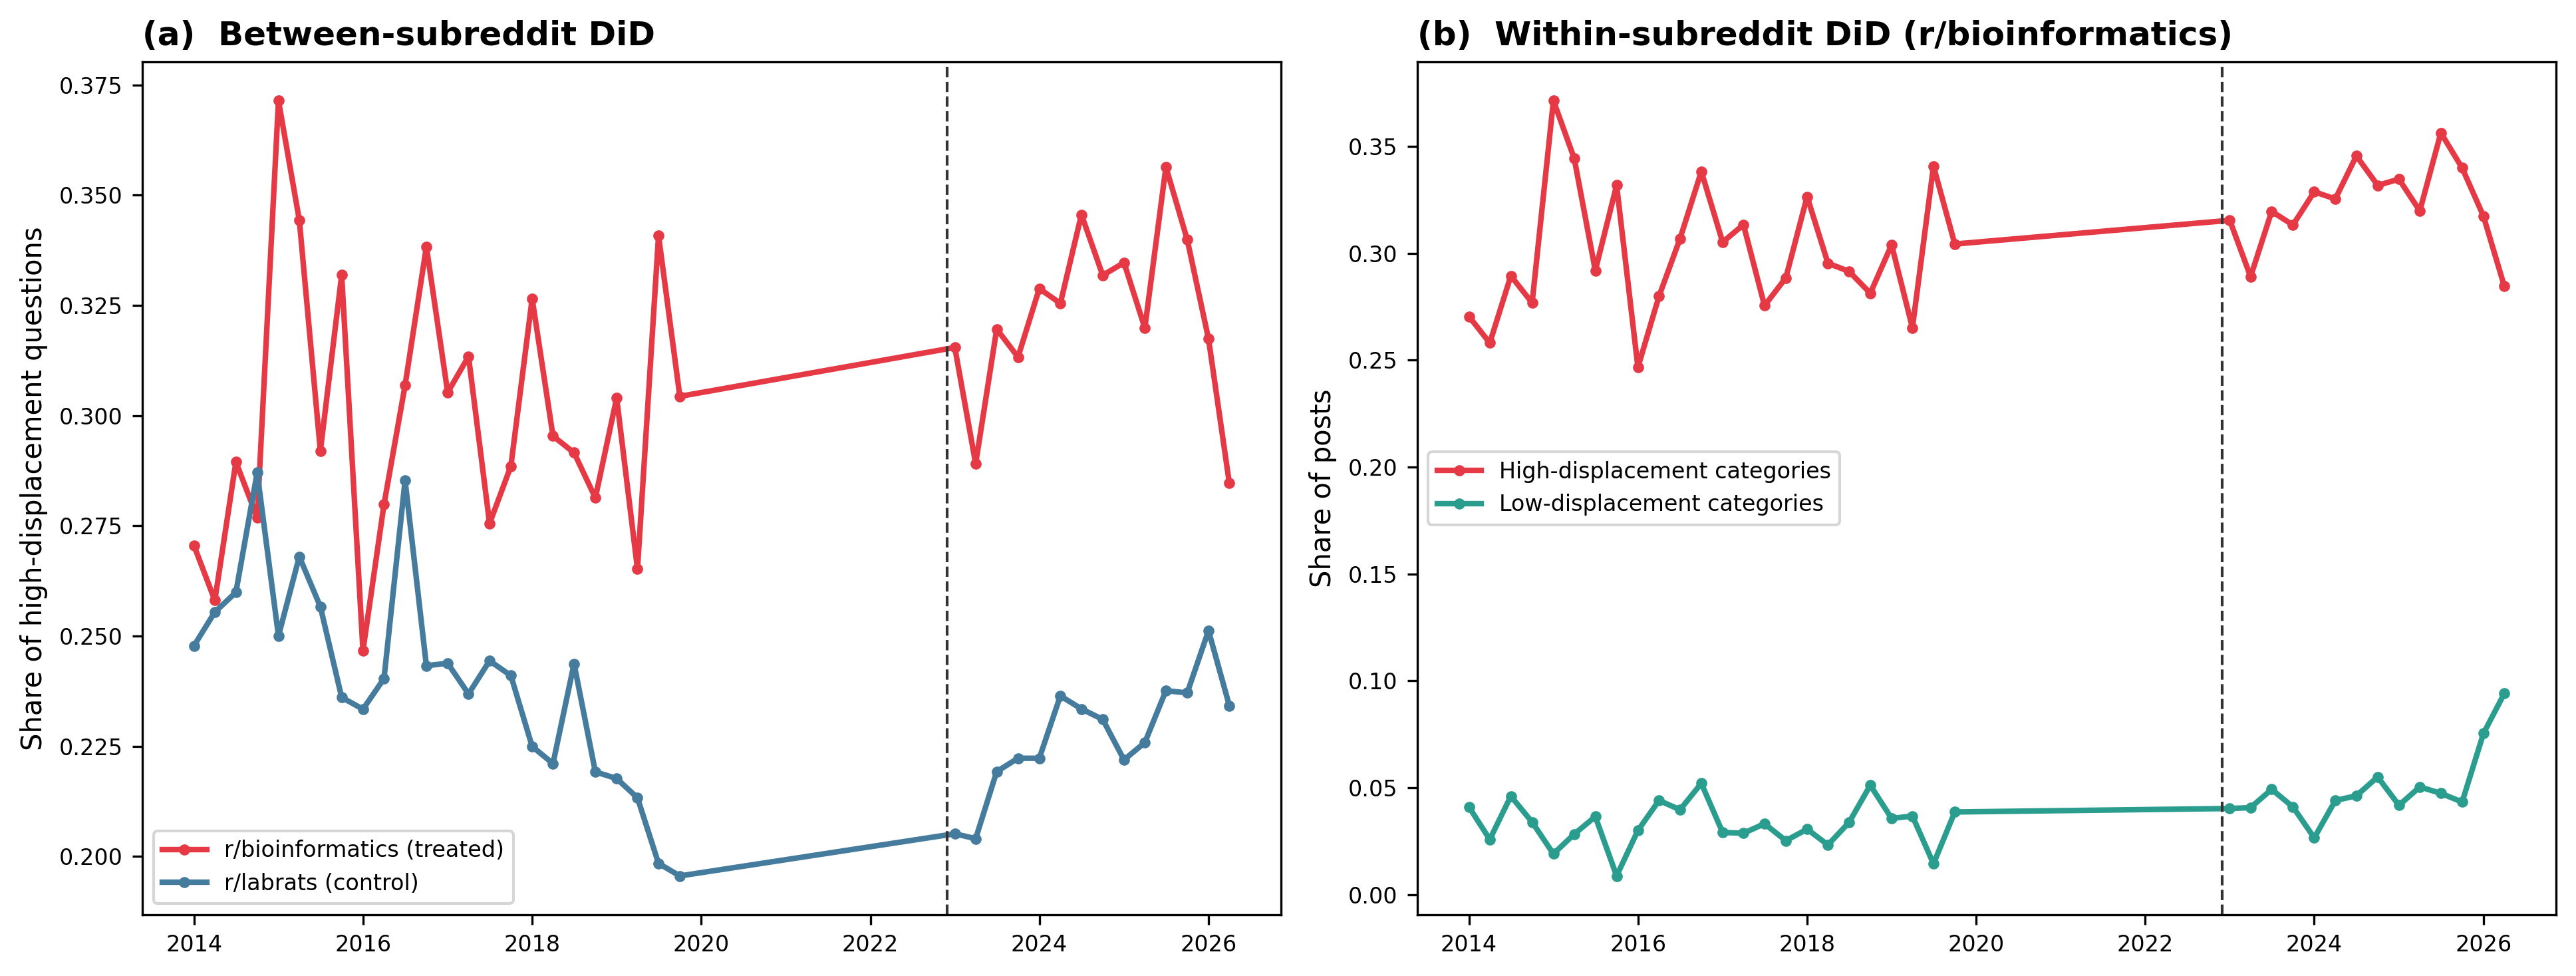

fig5_complexity_engagement.png


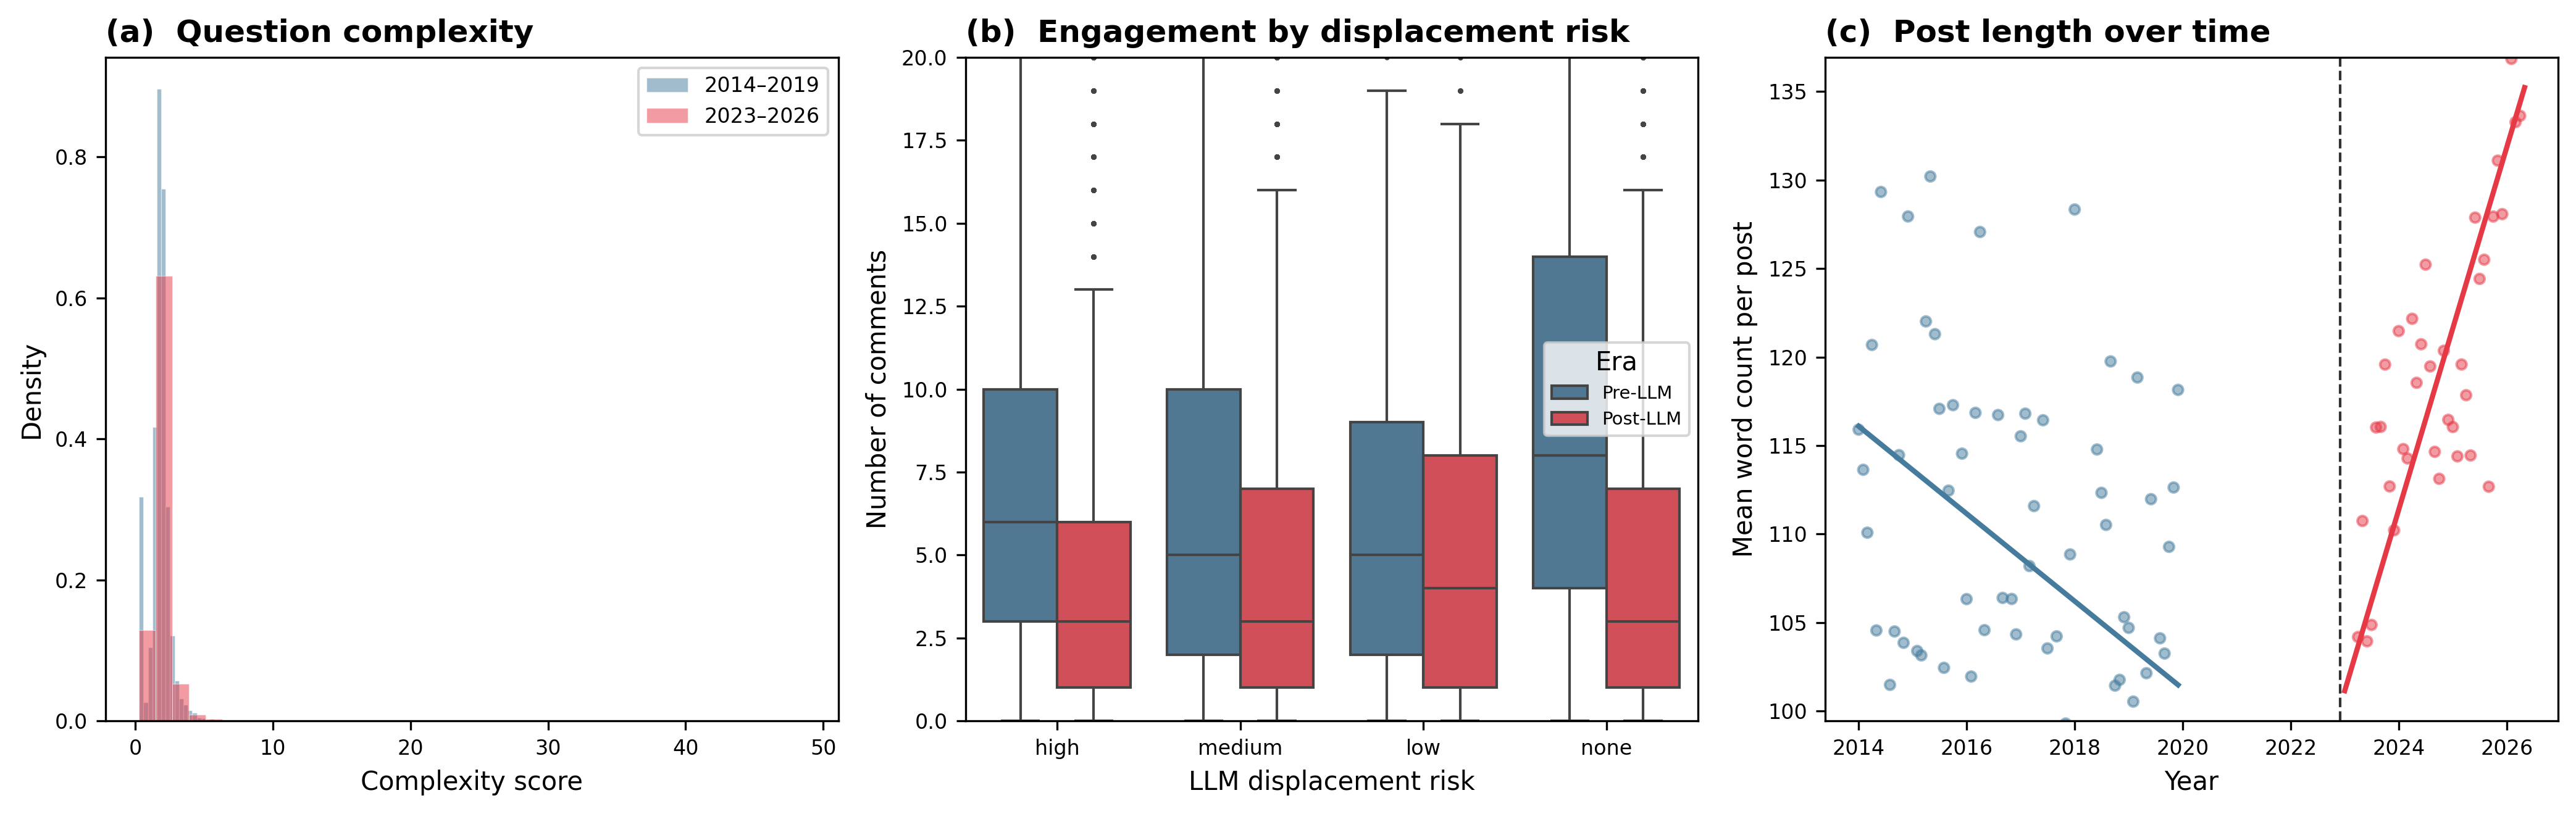

fig6_cross_subreddit.png


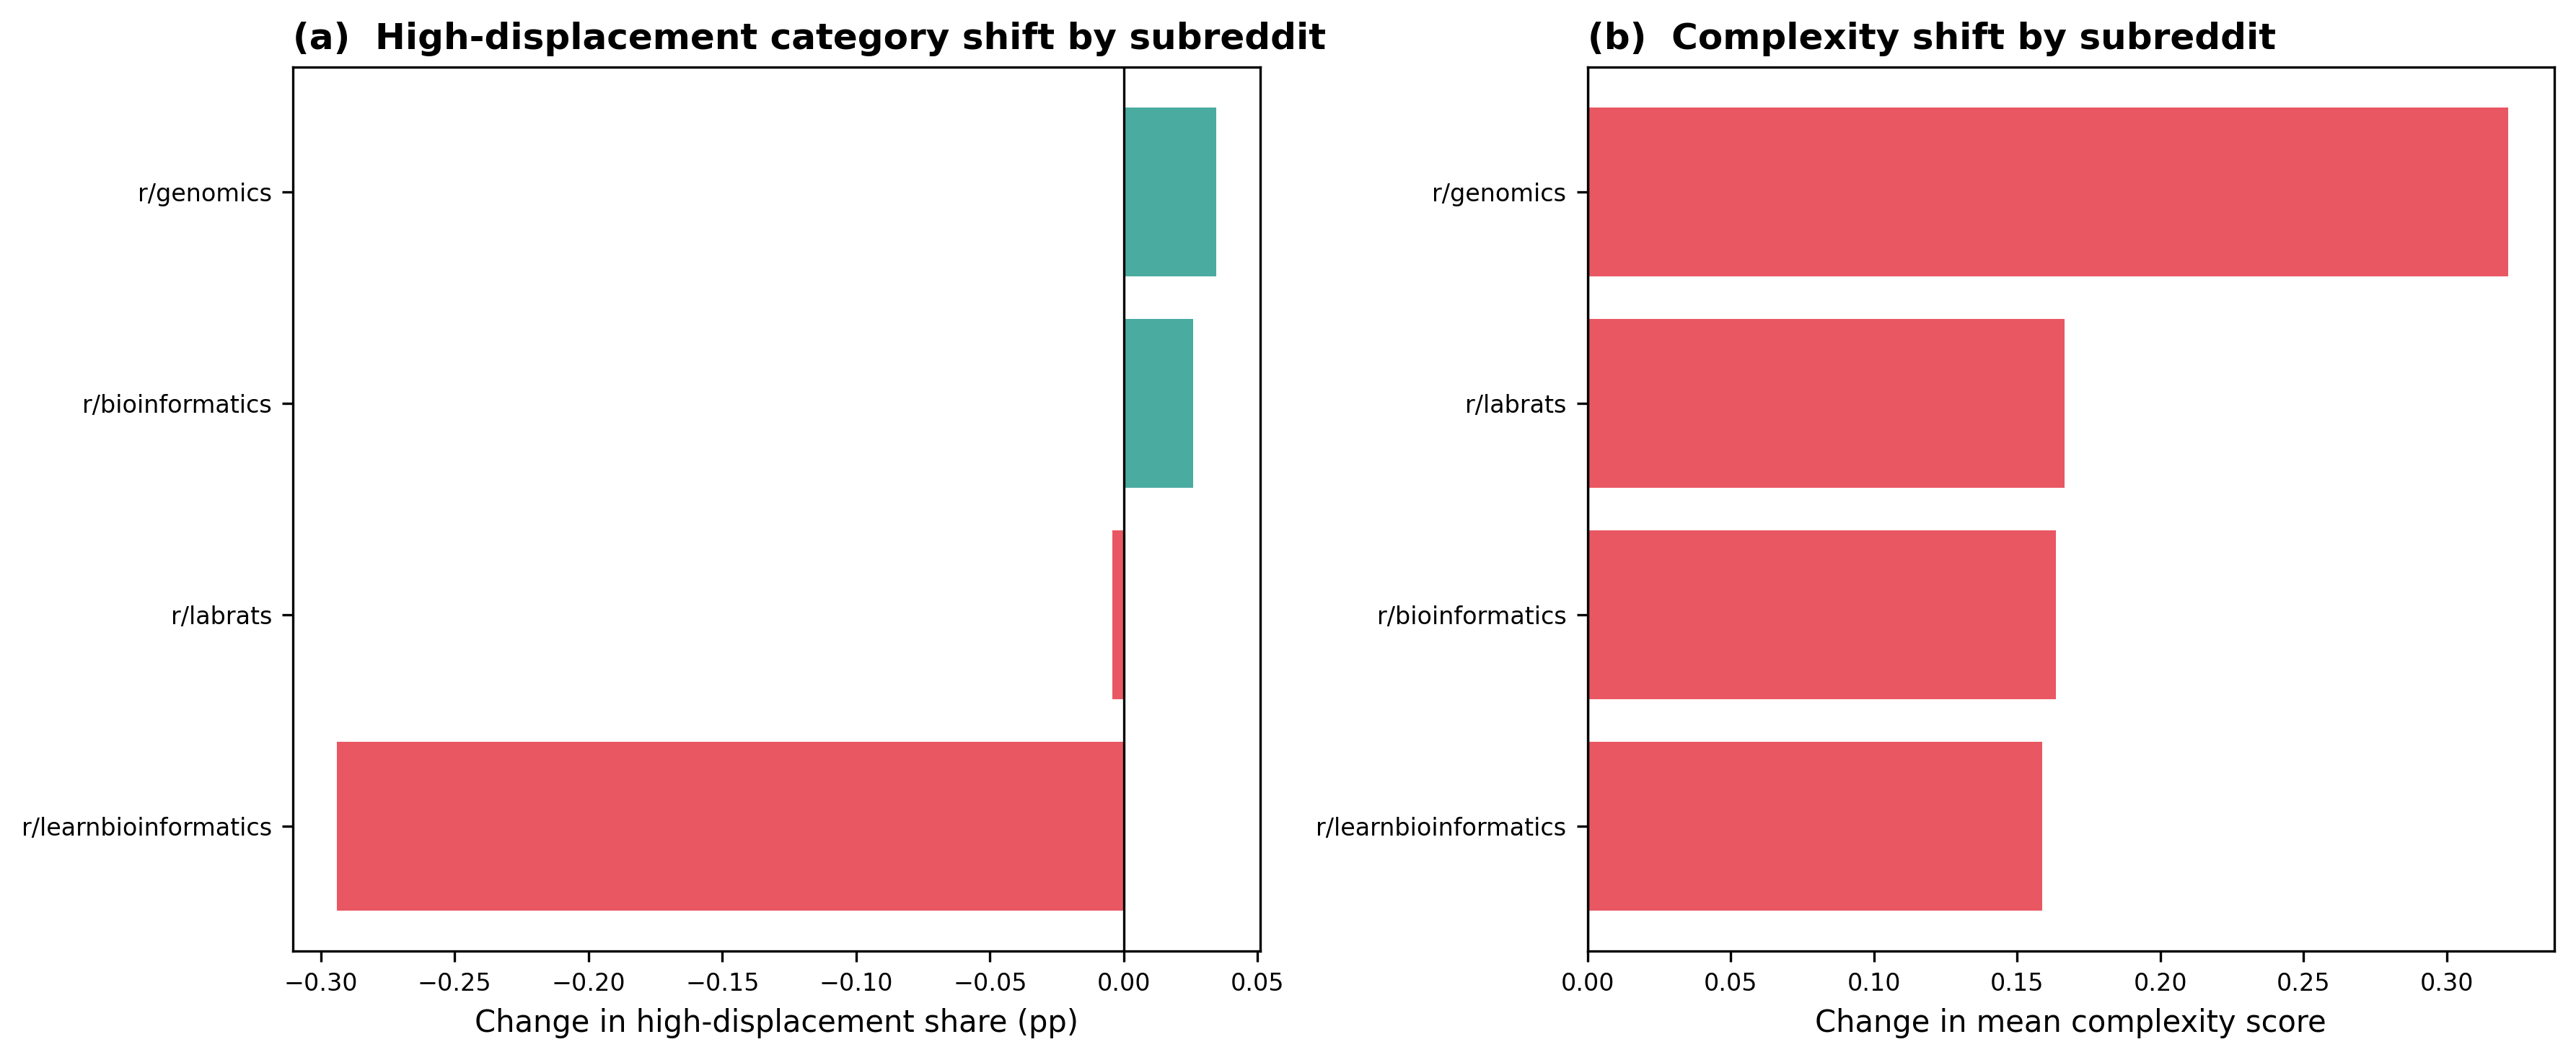

fig7_topic_diversity.png


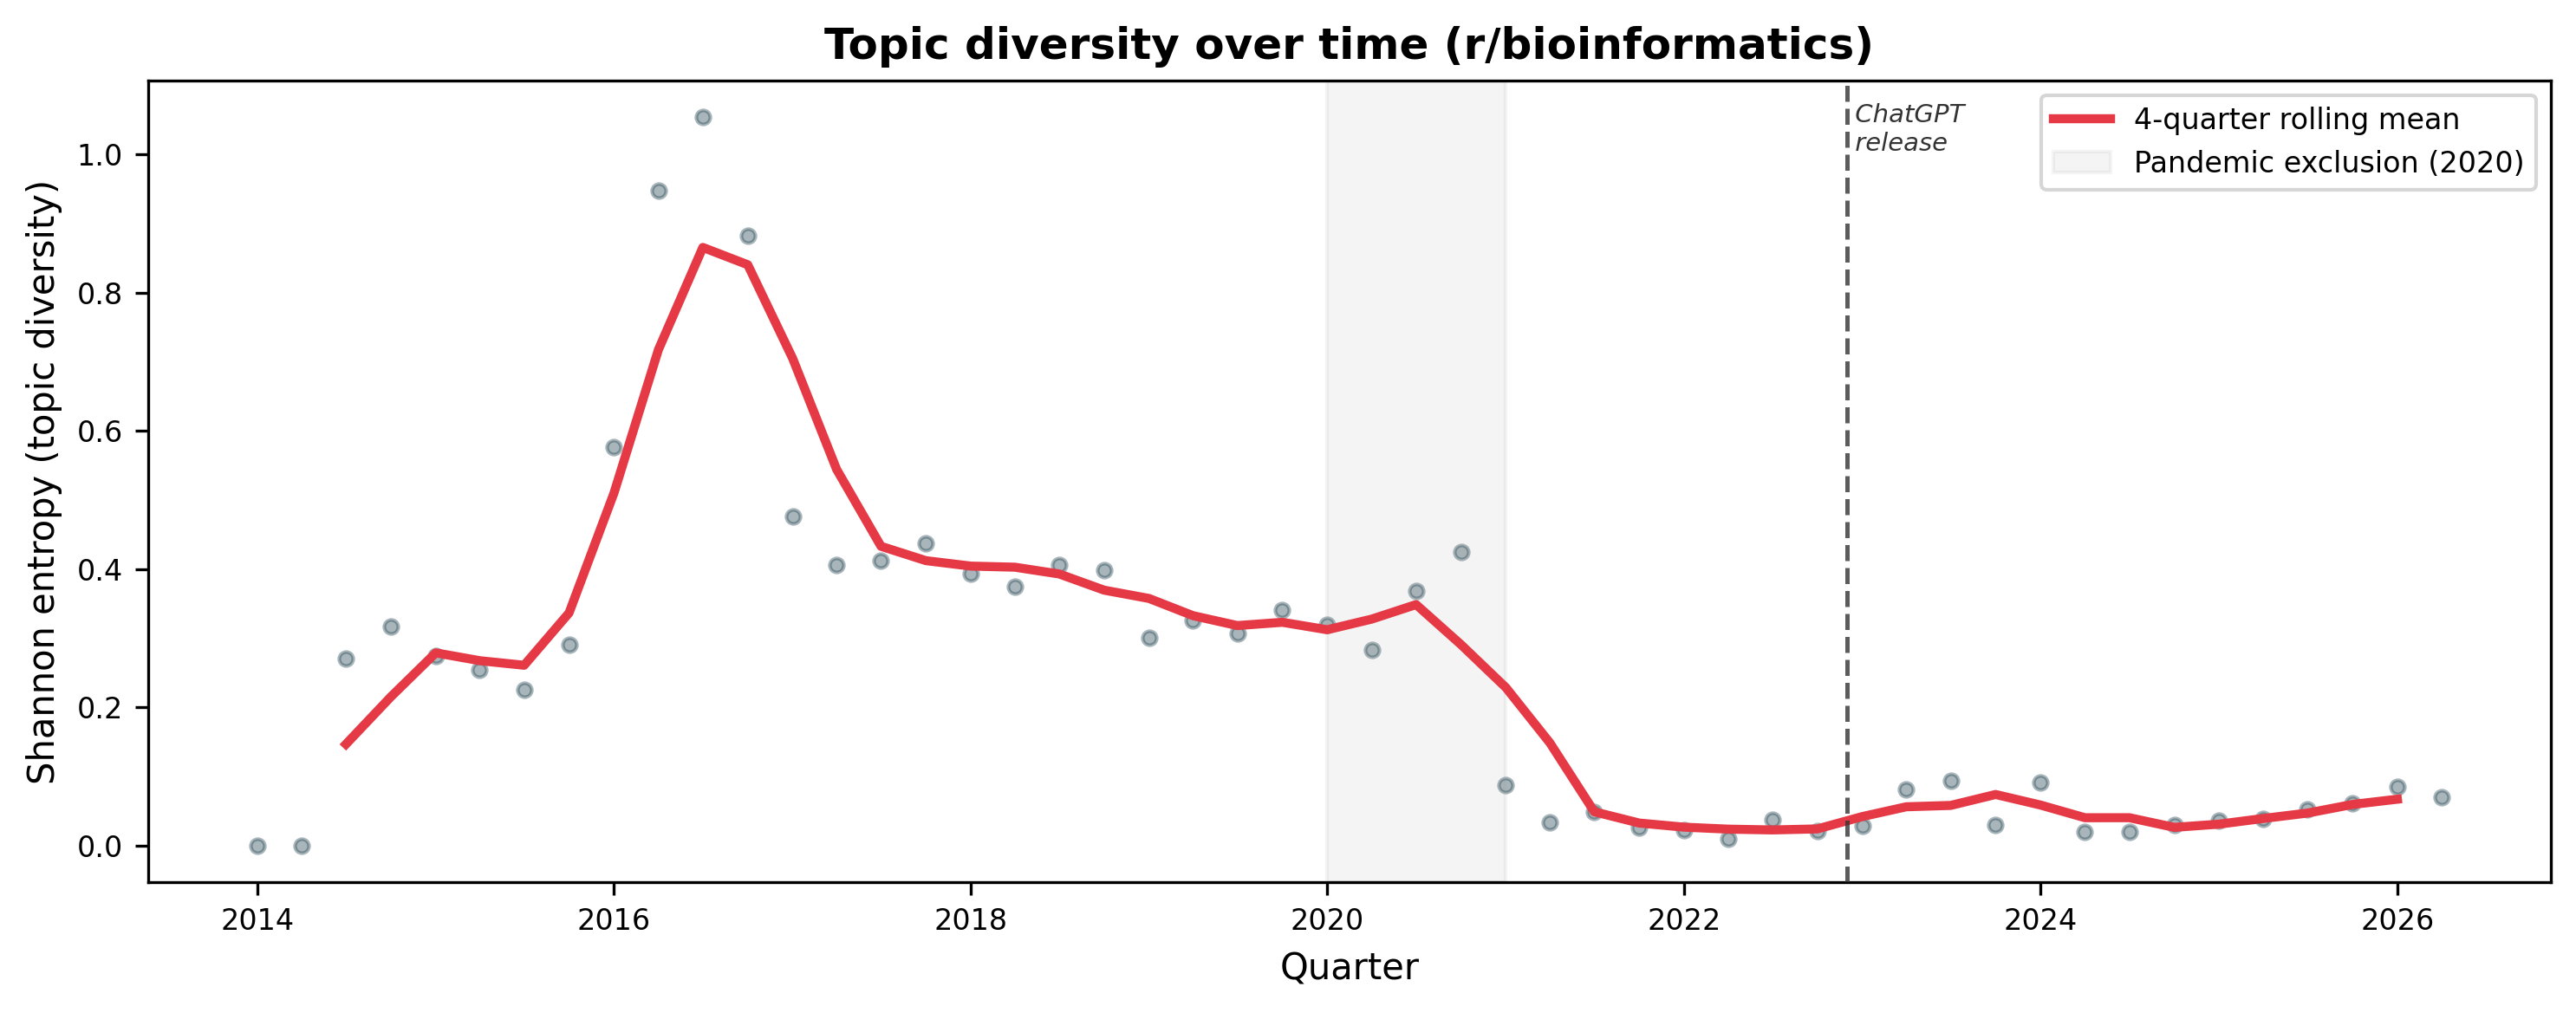

In [ ]:
from IPython.display import Image, display as ipy_display
for fig in sorted(os.listdir(FIG_DIR)):
    if fig.endswith(".png"):
        print(f"{fig}")
        ipy_display(Image(filename=f"{FIG_DIR}/{fig}", width=900))

## 11. Summary

In [ ]:
print("ANALYSIS COMPLETE")
print(f"  Posts: {len(df):,}")
n_tables = len([f for f in os.listdir(f"{WORK_DIR}/tables") if f.endswith(".csv")])
n_figs = len([f for f in os.listdir(FIG_DIR) if f.endswith(".png")])
print(f"  Tables: {n_tables} CSV files")
print(f"  Figures: {n_figs} PNG files")
print()
if len(hyp) > 0:
    for _, row in hyp.iterrows():
        s = "V" if row.get("significant_fdr", False) else "X"
        print(f"  {s} {row['hypothesis']}: {row['description']}")
        print(f"    {row['pre_value']} -> {row['post_value']} ({row['effect_size']})")
print()
print("Next steps:")
print("  1. Validate classifier with ~1,200 manually labeled posts")
print("  2. Review BERTopic topics for domain coherence")
print("  3. Pre-register on OSF before finalizing")

ANALYSIS COMPLETE
  Posts: 122,544
  Tables: 9 CSV files
  Figures: 7 PNG files

  V H2: Question complexity increases
    1.789 -> 1.953 (d=0.204)
  V H6: Beginner share declines
    0.085 -> 0.075 (-0.010 pp)
  V H3a: Total volume does NOT decline
    341/qtr -> 1175/qtr (ratio=3.45)
  V H1: High-displacement shares decline
    0.300 -> 0.326 (+0.026 pp)
  V H4: Topic diversity increases
    H=2.499 -> H=2.574 (ΔH=+0.076)
  X H3b: Displaceable volume declines
    102/qtr -> 384/qtr (ratio=3.75)
  X H5: Engagement improves
    7.86 -> 5.72 (Δ=-2.14)
  X H7: Career/meta NO break (control)
    0.170 -> 0.186 (+0.015 pp)

Next steps:
  1. Validate classifier with ~1,200 manually labeled posts
  2. Review BERTopic topics for domain coherence
  3. Pre-register on OSF before finalizing
